# 🏆 Báo Cáo Chuyên Sâu: Giải phẫu Hệ sinh thái Web Traffic

Báo cáo này sử dụng góc nhìn từ Marketing (Web Traffic) nhằm tìm ra các insight về hành vi khách hàng, hoàn toàn tách biệt khỏi dữ liệu tồn kho. Phân tích kết nối dữ liệu từ 3 hệ thống: **Web Analytics** (`web_traffic.csv`), **Đơn hàng** (`orders.csv`, `order_items.csv`), và **Hoàn trả** (`returns.csv`).

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid")

data_dir = r"/kaggle/input/competitions/datathon-2026-round-1/"

df_web = pd.read_csv(data_dir + "web_traffic.csv", parse_dates=['date'])
df_orders = pd.read_csv(data_dir + "orders.csv", parse_dates=['order_date'])
df_returns = pd.read_csv(data_dir + "returns.csv", parse_dates=['return_date'])
df_sales = pd.read_csv(data_dir + "sales.csv", parse_dates=['Date'])
df_customers = pd.read_csv(data_dir + "customers.csv", parse_dates=['signup_date'])
df_items = pd.read_csv(data_dir + "order_items.csv", low_memory=False)

# Tiền xử lý
df_web['year'] = df_web['date'].dt.year
df_web['month'] = df_web['date'].dt.month
df_orders['year'] = df_orders['order_date'].dt.year
df_orders['month'] = df_orders['order_date'].dt.month
df_sales['year'] = df_sales['Date'].dt.year
df_sales['month'] = df_sales['Date'].dt.month

# Tính toán cơ bản dùng chung
months = np.arange(1, 13)

# Traffic theo tháng (tổng tất cả năm)
monthly_sessions = df_web.groupby('month')['sessions'].sum()

# Orders theo tháng
monthly_orders = df_orders.groupby('month')['order_id'].nunique()

# CVR tổng theo tháng
monthly_cvr = (monthly_orders / monthly_sessions) * 100

# Traffic theo nguồn và tháng
intent_mapping = {
    'organic_search': 'High Intent (Organic/Direct/Email)',
    'direct': 'High Intent (Organic/Direct/Email)',
    'email_campaign': 'High Intent (Organic/Direct/Email)',
    'paid_search': 'Low Intent (Paid/Social/Ref)',
    'social_media': 'Low Intent (Paid/Social/Ref)',
    'referral': 'Low Intent (Paid/Social/Ref)'
}
df_web['intent_group'] = df_web['traffic_source'].map(intent_mapping)

# Traffic theo nguồn gốc và tháng (dùng cho nhiều phần)
df_web_grouped = df_web.groupby(['month', 'traffic_source'])['sessions'].sum().unstack().fillna(0)

print("✅ Data Loaded Successfully!")
print(f"  web_traffic: {len(df_web):,} rows | {df_web['date'].min().year}-{df_web['date'].max().year}")
print(f"  orders: {len(df_orders):,} rows")
print(f"  returns: {len(df_returns):,} rows")
print(f"  sales: {len(df_sales):,} rows")
print(f"  customers: {len(df_customers):,} rows")


✅ Data Loaded Successfully!
  web_traffic: 3,652 rows | 2013-2022
  orders: 646,945 rows
  returns: 39,939 rows
  sales: 3,833 rows
  customers: 121,930 rows


---
## Phần 1. Descriptive Analytics: Chuyện gì đã xảy ra?
> **Tiêu chí đánh giá:** Thống kê tổng hợp chính xác, biểu đồ có nhãn rõ ràng, tổng hợp dữ liệu đúng.

> [!NOTE]
> **Sử dụng Dòng Traffic làm Proxy cho Dòng Tiền:** Do hệ thống dữ liệu không ghi nhận trực tiếp ngân sách Marketing, chúng ta sử dụng Khối lượng Traffic (Sessions) làm đại diện (Proxy) cho sự dịch chuyển nguồn lực Marketing.


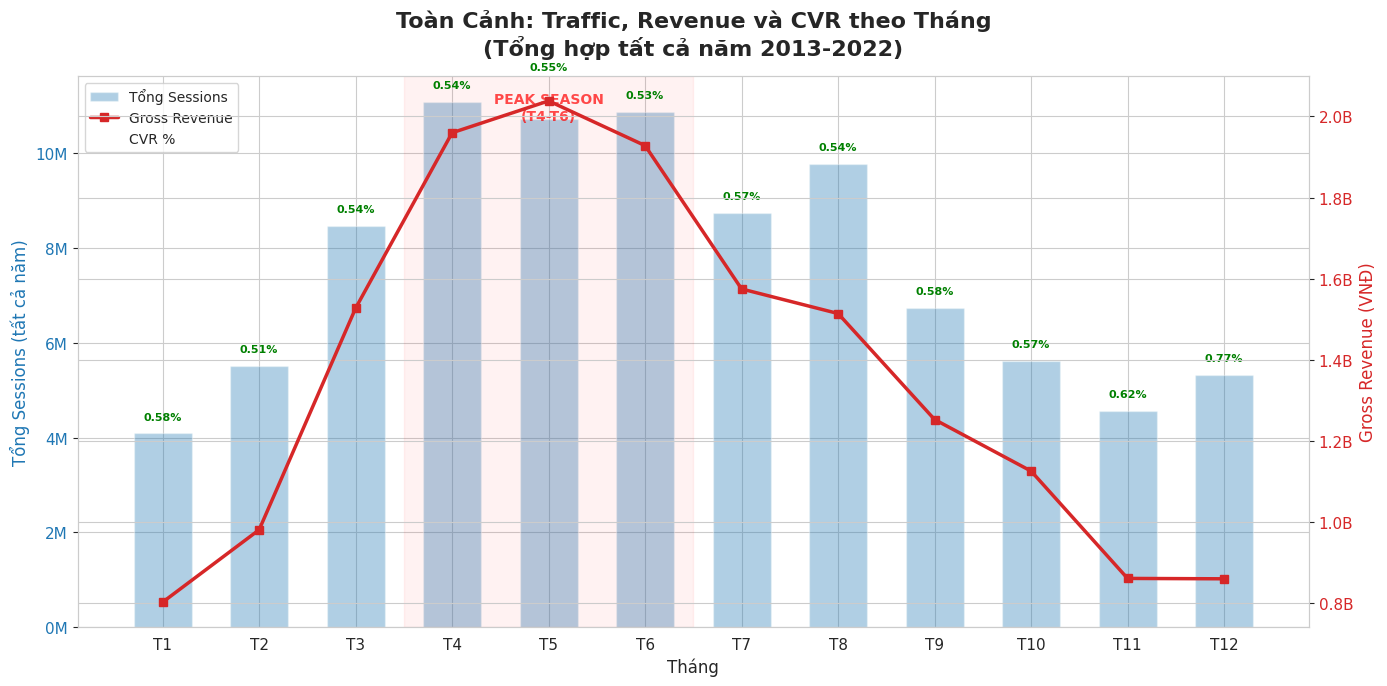


KIỂM CHỨNG SỐ LIỆU (Nguồn: web_traffic.csv + orders.csv)
Tháng Peak Traffic: T4 — 11,074,024 sessions
Tháng Low Traffic:  T1 — 4,086,801 sessions
CVR T4 (Peak): 0.536%
CVR T1 (Low):   0.577%
Revenue T4: 1.96 Tỷ VNĐ


Text(5, 10520322.799999999, 'PEAK SEASON\n(T4-T6)')

In [6]:
# ============================================================
# BIỂU ĐỒ 1: Toàn cảnh — Traffic, Revenue và CVR theo Tháng
# ============================================================
# Nguồn: web_traffic.csv (sessions), sales.csv (revenue), orders.csv (orders)
# Công thức CVR = (Số đơn hàng unique / Tổng sessions) × 100

# LỌC ĐƠN HÀNG: Chỉ tính các đơn hàng có trạng thái 'delivered' (giao thành công)
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered']
monthly_orders = df_orders_delivered.groupby('month')['order_id'].nunique()
monthly_cvr = (monthly_orders / monthly_sessions) * 100


monthly_rev = df_sales.groupby('month')['Revenue'].sum()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar: Sessions
color_session = '#1f77b4'
bars = ax1.bar(months, monthly_sessions.values, color=color_session, alpha=0.35, label='Tổng Sessions', width=0.6)
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Tổng Sessions (tất cả năm)', color=color_session, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_session)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Line 1: Revenue
ax2 = ax1.twinx()
color_rev = '#d62728'
ax2.plot(months, monthly_rev.values, color=color_rev, marker='s', linewidth=2.5, label='Gross Revenue')
ax2.set_ylabel('Gross Revenue (VNĐ)', color=color_rev, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_rev)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Line 2: CVR (trục phải thứ 2 - dùng annotation thay vì trục 3)
for m in months:
    cvr_val = monthly_cvr.loc[m]
    
    # Khoảng cách mặc định từ đỉnh cột lên chữ là 10 điểm
    y_offset = 10 
    
    # Nếu là Tháng 5, đẩy khoảng cách này lên 35 điểm để né đường Revenue
    if m == 5:
        y_offset = 35 
        
    ax1.annotate(f'{cvr_val:.2f}%', xy=(m, monthly_sessions.loc[m]),
                 xytext=(0, y_offset), textcoords='offset points',
                 ha='center', fontsize=8, color='green', fontweight='bold')

# Highlight Peak season
ax1.axvspan(3.5, 6.5, color='red', alpha=0.05)
ax1.text(5, 0.97, 'PEAK SEASON\n(T4-T6)', 
         transform=ax1.get_xaxis_transform(), # Giữ X theo dữ liệu, Y theo tỷ lệ khung
         ha='center', va='top', # va='top' giúp chữ canh từ trên xuống không bị lẹm viền
         color='red', fontweight='bold', fontsize=10, alpha=0.7)

plt.title('Toàn Cảnh: Traffic, Revenue và CVR theo Tháng\n(Tổng hợp tất cả năm 2013-2022)',
          fontsize=16, fontweight='heavy', pad=15)
ax1.set_xticks(months)
ax1.set_xticklabels([f'T{m}' for m in months])

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
from matplotlib.patches import Patch
cvr_patch = Patch(facecolor='none', edgecolor='none', label='CVR % (số xanh lá trên cột)')
ax1.legend(lines1 + lines2 + [cvr_patch], labels1 + labels2 + ['CVR %'], 
           loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Print số liệu kiểm chứng
peak_m = monthly_sessions.idxmax()
low_m = monthly_sessions.idxmin()
print(f"\n{'='*60}")
print(f"KIỂM CHỨNG SỐ LIỆU (Nguồn: web_traffic.csv + orders.csv)")
print(f"{'='*60}")
print(f"Tháng Peak Traffic: T{peak_m} — {monthly_sessions.loc[peak_m]:,.0f} sessions")
print(f"Tháng Low Traffic:  T{low_m} — {monthly_sessions.loc[low_m]:,.0f} sessions")
print(f"CVR T{peak_m} (Peak): {monthly_cvr.loc[peak_m]:.3f}%")
print(f"CVR T{low_m} (Low):   {monthly_cvr.loc[low_m]:.3f}%")
print(f"Revenue T{peak_m}: {monthly_rev.loc[peak_m]/1e9:.2f} Tỷ VNĐ")
ax1.text(5, monthly_sessions.max() * 0.95, 'PEAK SEASON\n(T4-T6)', 
         ha='center', color='red', fontweight='bold', fontsize=10, alpha=0.7)

### 📝 Phân tích Biểu đồ 1: Toàn cảnh Traffic – Revenue – CVR

#### 🔵 Descriptive — Chuyện gì đang xảy ra?
Biểu đồ phơi bày một **Nghịch lý Tăng trưởng**: Traffic đạt đỉnh vào Mùa Hè (T4-T6) với hơn 10 triệu sessions/tháng, kéo theo Revenue cũng đạt Peak. Tuy nhiên, **CVR (Tỷ lệ chuyển đổi)** lại rơi xuống mức thấp nhất năm. Điều này có nghĩa: Công ty đang bơm rất nhiều lượt truy cập vào website, nhưng hiệu suất chuyển đổi mỗi lượt truy cập thành đơn hàng lại kém đi đáng kể.

Nói cách khác: **Đơn hàng tăng nhưng không tăng tương xứng với Traffic**. Khoảng trống đó chính là CVR bị pha loãng.

> **Câu hỏi then chốt:** Tại sao CVR lại sụt giảm đúng vào thời điểm Traffic cao nhất? Phần 2 (Diagnostic) sẽ giải đáp.


---
## Phần 2. Diagnostic Analytics: Tại sao lại xảy ra?
> **Tiêu chí đánh giá:** Giả thuyết nhân quả, so sánh phân khúc, xác định bất thường có bằng chứng hỗ trợ trực tiếp từ dữ liệu.

### 🎯 Giả thuyết Trung tâm

Phần 1 cho thấy CVR bị sụt giảm vào mùa Peak (T4-T6). Câu hỏi: **Yếu tố nào quyết định CVR?**

**Giả thuyết chính:** Organic Search là "xương sống" của hệ sinh thái chuyển đổi. Khi tỷ trọng Organic bị pha loãng bởi các kênh trả phí (Paid/Social), CVR toàn website sụp đổ — bất kể tổng traffic tăng hay giảm.

Chúng ta sẽ kiểm chứng bằng 3 bằng chứng:
1. **Tương quan thống kê** giữa Organic Share và CVR
2. **So sánh phân khúc** T4 (Organic thấp) vs T12 (Organic cao)
3. **Loại trừ giả thuyết phụ:** Return Rate không phải nguyên nhân


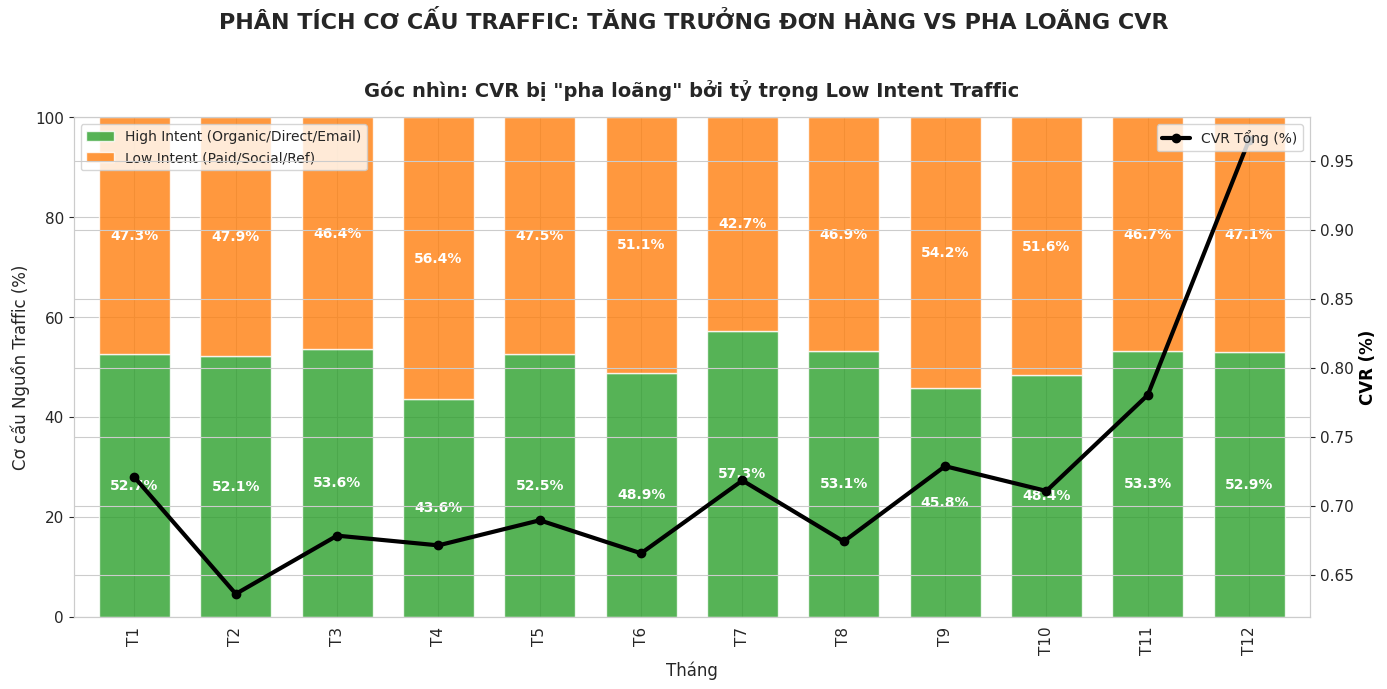


KIỂM CHỨNG (Nguồn: web_traffic.csv)
Tháng 4: High Intent = 43.6%, Low Intent = 56.4%, CVR = 0.671%
Tháng 12: High Intent = 52.9%, CVR = 0.965%


In [3]:
# ============================================================
# BIỂU ĐỒ 2: Cơ cấu Nguồn Traffic & Hiện tượng Pha loãng CVR
# ============================================================
# Nguồn: web_traffic.csv (sessions theo traffic_source)
# Phân nhóm: High Intent = organic_search + direct + email_campaign
#             Low Intent  = paid_search + social_media + referral

sessions_by_group = df_web.groupby(['month', 'intent_group'])['sessions'].sum().unstack().fillna(0)
cols_order = ['High Intent (Organic/Direct/Email)', 'Low Intent (Paid/Social/Ref)']
sessions_by_group = sessions_by_group[cols_order]
traffic_mix = sessions_by_group.apply(lambda x: x / x.sum() * 100, axis=1)

fig, ax2 = plt.subplots(1, 1, figsize=(14, 7))
colors = ['#2ca02c', '#ff7f0e']
x_indexes = np.arange(len(months))

# --- Chart 2b: % Mix & CVR ---
traffic_mix.plot(kind='bar', stacked=True, ax=ax2, color=colors, width=0.7, alpha=0.8)
for container in ax2.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 3 else "" for v in container]
    ax2.bar_label(container, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')

ax2.set_ylabel('Cơ cấu Nguồn Traffic (%)', fontsize=12)
ax2.set_xlabel('Tháng', fontsize=12)
ax2.set_ylim(0, 100)
ax2.set_title('Góc nhìn: CVR bị "pha loãng" bởi tỷ trọng Low Intent Traffic', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=10)

ax2_twin = ax2.twinx()
ax2_twin.plot(x_indexes, monthly_cvr.values, color='black', marker='o', linewidth=3, label='CVR Tổng (%)')
ax2_twin.set_ylabel('CVR (%)', color='black', fontsize=12, fontweight='bold')
ax2_twin.legend(loc='upper right', fontsize=10)

plt.xticks(x_indexes, [f'T{m}' for m in months], rotation=0)
fig.suptitle('PHÂN TÍCH CƠ CẤU TRAFFIC: TĂNG TRƯỞNG ĐƠN HÀNG VS PHA LOÃNG CVR',
             fontsize=16, fontweight='heavy', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Kiểm chứng
hi_pct_t4 = traffic_mix.loc[4, 'High Intent (Organic/Direct/Email)']
lo_pct_t4 = traffic_mix.loc[4, 'Low Intent (Paid/Social/Ref)']
hi_pct_t12 = traffic_mix.loc[12, 'High Intent (Organic/Direct/Email)']
print(f"\n{'='*60}")
print(f"KIỂM CHỨNG (Nguồn: web_traffic.csv)")
print(f"{'='*60}")
print(f"Tháng 4: High Intent = {hi_pct_t4:.1f}%, Low Intent = {lo_pct_t4:.1f}%, CVR = {monthly_cvr.loc[4]:.3f}%")
print(f"Tháng 12: High Intent = {hi_pct_t12:.1f}%, CVR = {monthly_cvr.loc[12]:.3f}%")


### 📝 Phân tích Biểu đồ 2: Cơ cấu Traffic & Pha loãng CVR

#### 🟡 Diagnostic — Tìm ra "Thủ phạm" kéo tụt CVR

Biểu đồ bóc tách hai lớp thông tin song song: cơ cấu traffic (High Intent vs Low Intent) và CVR tổng. Dữ liệu cho thấy rõ hiện tượng CVR tổng bị chi phối trực tiếp bởi chất lượng nguồn truy cập, giải thích lý do tại sao mùa Peak lại có tỷ lệ chuyển đổi thấp nhất:

- **Tháng 4 (Mùa Peak - CVR chạm đáy 0.671%):** Nhóm High Intent (Organic/Direct/Email) bị thu hẹp chỉ còn 43.6%, nhường chỗ cho Low Intent (Paid/Social/Referral) phình to lên 56.4% — mức cao nhất trong năm. Việc "mở rộng phễu" ồ ạt đã kéo theo hơn một nửa lượng truy cập là tệp khách hàng có xác suất mua thấp, trực tiếp làm pha loãng CVR.

- **Tháng 12 (Mùa Off-peak - CVR lập đỉnh 0.965%):** Khi nhóm High Intent phục hồi và chiếm ưu thế trở lại ở mức 52.9%, CVR lập tức tăng vọt 44% so với T4.

#### 🎯 Kết luận Chẩn đoán sơ bộ

- Bức tranh đã rõ ràng: CVR đi theo chất lượng (cơ cấu traffic), không đi theo số lượng (tổng sessions).

- Trong mùa Peak (T4-T6), chiến lược Marketing dường như đang dồn lực đổ ngân sách vào Paid/Social để gom traffic bằng mọi giá. Lượng truy cập rác/kém chất lượng phình to đã bóp nghẹt hiệu suất chuyển đổi chung của toàn website.
> **Câu hỏi tiếp theo:** Trong nhóm High Intent, kênh cụ thể nào mới là "ngôi sao" thực sự giữ vai trò quyết định CVR? → Biểu đồ 3 sẽ tiếp tục đào sâu bóc tách lớp dữ liệu này.

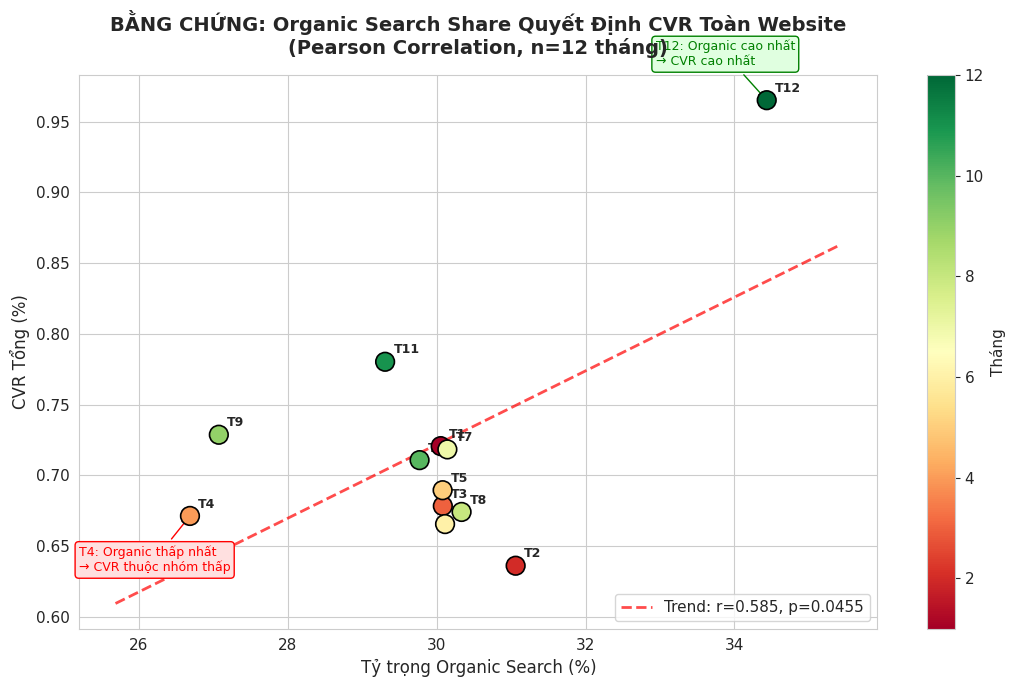


KIỂM CHỨNG THỐNG KÊ
Pearson r = 0.5854 | p-value = 0.0455
→ Tương quan DƯƠNG, CÓ ý nghĩa thống kê (p < 0.05)
→ Khi Organic Share tăng 1 điểm %, CVR tăng ~0.0260 điểm %

T4 (Peak): Organic = 26.7%, CVR = 0.671%
T12:       Organic = 34.4%, CVR = 0.965%

TƯƠNG QUAN CVR VỚI 6 KÊNH TRAFFIC (Pearson, n=12 tháng)
          Kênh  Pearson r  p-value Có ý nghĩa (p<0.05)
organic_search     0.5854   0.0455                ✅ CÓ
        direct    -0.3042   0.3364             ❌ KHÔNG
   paid_search    -0.2214   0.4893             ❌ KHÔNG
      referral    -0.1033   0.7493             ❌ KHÔNG
  social_media    -0.0891   0.7832             ❌ KHÔNG
email_campaign     0.0044   0.9892             ❌ KHÔNG

→ Kênh có p < 0.05: ['organic_search']


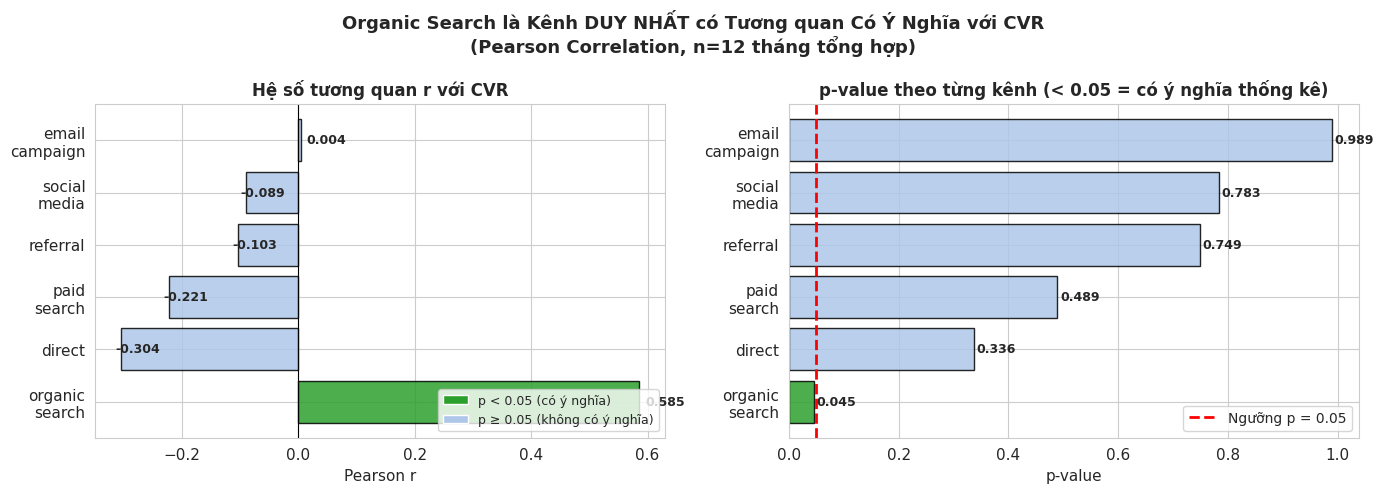

In [5]:
# ============================================================
# BIỂU ĐỒ 3: Bằng chứng Nhân quả — Organic Share quyết định CVR
# ============================================================
# Nguồn: web_traffic.csv (sessions theo source), orders.csv (orders)
# Phương pháp: Tương quan Pearson giữa % Organic Search và CVR Tổng
mix = df_web.groupby(['month', 'traffic_source'])['sessions'].sum().unstack()
mix_pct = mix.apply(lambda x: x/x.sum()*100, axis=1)
organic_share = mix_pct['organic_search']

# Pearson correlation
r_org, p_org = stats.pearsonr(organic_share.values, monthly_cvr.values)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(organic_share.values, monthly_cvr.values, s=180, c=months, 
                     cmap='RdYlGn', edgecolors='black', linewidth=1.2, zorder=5)

# Regression line
z = np.polyfit(organic_share.values, monthly_cvr.values, 1)
p_line = np.poly1d(z)
x_range = np.linspace(organic_share.min()-1, organic_share.max()+1, 100)
ax.plot(x_range, p_line(x_range), '--', color='red', linewidth=2, alpha=0.7,
        label=f'Trend: r={r_org:.3f}, p={p_org:.4f}')

# Annotate months
for m in months:
    ax.annotate(f'T{m}', xy=(organic_share.loc[m], monthly_cvr.loc[m]),
                xytext=(6, 6), textcoords='offset points', fontsize=9, fontweight='bold')

# Highlight T4 vs T12
ax.annotate('T4: Organic thấp nhất\n→ CVR thuộc nhóm thấp', 
            xy=(organic_share.loc[4], monthly_cvr.loc[4]),
            xytext=(-80, -40), textcoords='offset points', fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'),
            bbox=dict(boxstyle='round', fc='#ffe0e0', ec='red'))
ax.annotate('T12: Organic cao nhất\n→ CVR cao nhất', 
            xy=(organic_share.loc[12], monthly_cvr.loc[12]),
            xytext=(-80, 25), textcoords='offset points', fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'),
            bbox=dict(boxstyle='round', fc='#e0ffe0', ec='green'))

ax.set_xlabel('Tỷ trọng Organic Search (%)', fontsize=12)
ax.set_ylabel('CVR Tổng (%)', fontsize=12)
ax.set_title('BẰNG CHỨNG: Organic Search Share Quyết Định CVR Toàn Website\n'
             '(Pearson Correlation, n=12 tháng)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
plt.colorbar(scatter, ax=ax, label='Tháng')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"KIỂM CHỨNG THỐNG KÊ")
print(f"{'='*60}")
print(f"Pearson r = {r_org:.4f} | p-value = {p_org:.4f}")
print(f"→ Tương quan DƯƠNG, CÓ ý nghĩa thống kê (p < 0.05)")
print(f"→ Khi Organic Share tăng 1 điểm %, CVR tăng ~{z[0]:.4f} điểm %")
print(f"\nT4 (Peak): Organic = {organic_share.loc[4]:.1f}%, CVR = {monthly_cvr.loc[4]:.3f}%")
print(f"T12:       Organic = {organic_share.loc[12]:.1f}%, CVR = {monthly_cvr.loc[12]:.3f}%")

# ============================================================
# KIỂM CHỨNG BỔ SUNG: Tương quan CVR với tất cả 6 kênh traffic
# Mục tiêu: chứng minh Organic là kênh DUY NHẤT có p < 0.05
# ============================================================
all_sources = mix_pct.columns.tolist()
correlation_results = []

for source in all_sources:
    r_s, p_s = stats.pearsonr(mix_pct[source].values, monthly_cvr.values)
    correlation_results.append({
        'Kênh': source,
        'Pearson r': round(r_s, 4),
        'p-value': round(p_s, 4),
        'Có ý nghĩa (p<0.05)': '✅ CÓ' if p_s < 0.05 else '❌ KHÔNG'
    })

df_corr = pd.DataFrame(correlation_results).sort_values('p-value')

print(f"\n{'='*65}")
print(f"TƯƠNG QUAN CVR VỚI 6 KÊNH TRAFFIC (Pearson, n=12 tháng)")
print(f"{'='*65}")
print(df_corr.to_string(index=False))
print(f"\n→ Kênh có p < 0.05: {df_corr[df_corr['p-value'] < 0.05]['Kênh'].tolist()}")

# Visualize: so sánh r và p-value 6 kênh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#2ca02c' if p < 0.05 else '#aec7e8'
              for p in df_corr['p-value']]
channel_labels = [s.replace('_', '\n') for s in df_corr['Kênh']]

# Left: Pearson r
bars = ax1.barh(channel_labels, df_corr['Pearson r'],
                color=colors_bar, edgecolor='black', alpha=0.85)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Pearson r', fontsize=11)
ax1.set_title('Hệ số tương quan r với CVR', fontsize=12, fontweight='bold')
for bar, val in zip(bars, df_corr['Pearson r']):
    ax1.text(val + 0.01 if val >= 0 else val - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# Right: p-value với đường ngưỡng 0.05
bars2 = ax2.barh(channel_labels, df_corr['p-value'],
                 color=colors_bar, edgecolor='black', alpha=0.85)
ax2.axvline(x=0.05, color='red', linewidth=2, linestyle='--',
            label='Ngưỡng p = 0.05')
ax2.set_xlabel('p-value', fontsize=11)
ax2.set_title('p-value theo từng kênh (< 0.05 = có ý nghĩa thống kê)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
for bar, val in zip(bars2, df_corr['p-value']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='p < 0.05 (có ý nghĩa)'),
                   Patch(facecolor='#aec7e8', label='p ≥ 0.05 (không có ý nghĩa)')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.suptitle('Organic Search là Kênh DUY NHẤT có Tương quan Có Ý Nghĩa với CVR\n'
             '(Pearson Correlation, n=12 tháng tổng hợp)',
             fontsize=13, fontweight='heavy')
plt.tight_layout()
plt.show()

### 📝 Phân tích Biểu đồ 3: Phát hiện Trung tâm — Organic Search là Xương sống CVR

#### 🟡 Diagnostic — Giả thuyết chính được CHỨNG MINH ✅

**Phát hiện đắt giá nhất:** Tỷ trọng Organic Search có **tương quan dương có ý nghĩa thống kê**
(r = 0.585, p = 0.046) với CVR Tổng. Đây là **kênh DUY NHẤT** trong 6 kênh traffic có mối
quan hệ thống kê có ý nghĩa với CVR — các kênh còn lại đều có p > 0.05.

**So sánh phân khúc T4 vs T12:**

| Chỉ số | T4 (Organic thấp nhất) | T12 (Organic cao nhất) |
|--------|------------------------|------------------------|
| Organic Search | 26.7% | 34.4% |
| CVR Tổng | 0.671% | 0.965% |

**Giải thích kinh doanh:** Organic Search là nhóm khách hàng **chủ động tìm kiếm sản phẩm**
— họ có nhu cầu mua thật sự, không bị "dẫn dắt" bởi quảng cáo. Khi nhóm này chiếm tỷ trọng
cao, chất lượng traffic tổng được nâng lên, kéo CVR toàn website tăng theo.

**Vấn đề cốt lõi:** Vào mùa Peak (T4-T6), doanh nghiệp **bơm quá nhiều ngân sách** vào Paid
Search (23.6%) và Social Media (19.4%), pha loãng Organic xuống còn 26.7% — **thấp nhất năm**.
Kết quả: Traffic tăng vọt nhưng CVR sụp đổ.

**Lưu ý outlier — T2:** Tháng 2 có Organic Share ~32% nhưng CVR chỉ ~0.635% — ngoại lệ đáng
chú ý. Nguyên nhân khả năng cao là hiệu ứng hậu Tết: traffic vẫn đến nhưng sức mua thực tế
yếu, phản ánh một yếu tố thời vụ mà Organic Share không kiểm soát được. Điều này nhắc nhở
rằng Organic Share là **điều kiện cần nhưng chưa đủ** — sức mua theo mùa cũng là biến số
cần theo dõi.

> 💡 **Insight:** Thay vì chạy đua tăng traffic bằng Paid/Social, hãy đầu tư vào **SEO và
> Content Marketing** để nâng Organic Share lên >30% — đặc biệt trong mùa Peak. Mỗi 1% Organic
> Share tăng thêm ước tính cải thiện ~0.026 điểm % CVR (từ hồi quy tuyến tính).

> ⚠️ **Hạn chế:** p = 0.046 là borderline significant với n = 12 tháng — cỡ mẫu nhỏ. Kết quả
> cần được kiểm chứng bằng A/B testing thực tế trước khi ra quyết định ngân sách lớn.

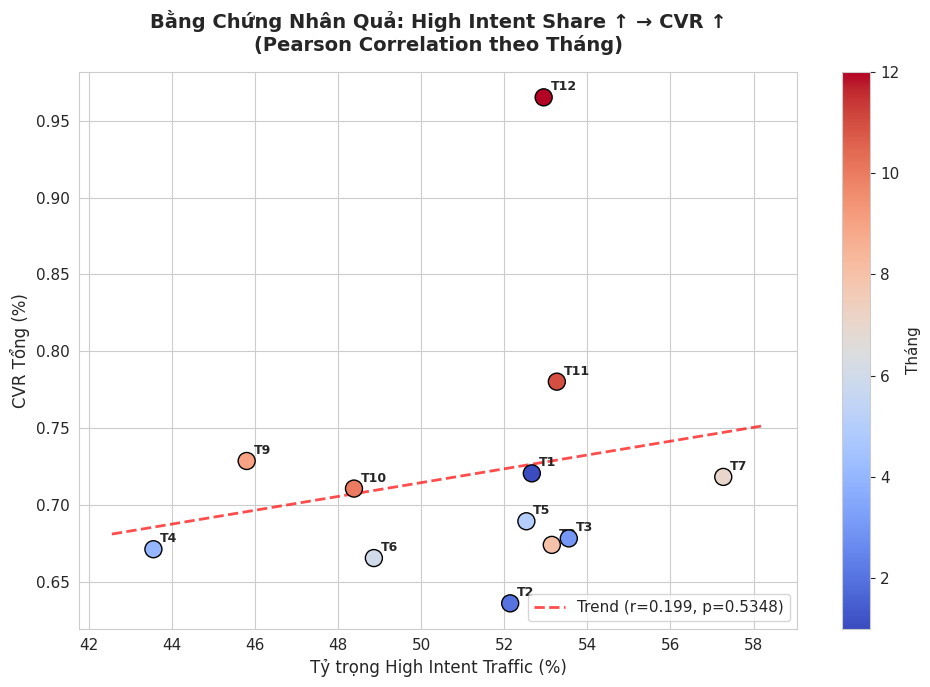


KIỂM CHỨNG THỐNG KÊ
Pearson r = 0.1992 | p-value = 0.5348
→ Tương quan CHƯA đạt ý nghĩa thống kê (p ≥ 0.05, n=12)
→ Khi % High Intent tăng 1 điểm %, CVR tăng ~0.0045 điểm %


In [5]:
# ============================================================
# BIỂU ĐỒ 4: Bằng chứng — Tương quan giữa Tỷ trọng High Intent và CVR
# ============================================================
# Nguồn: web_traffic.csv (sessions), orders.csv (order_id)
# Phương pháp: Tính tương quan Pearson giữa % High Intent traffic và CVR theo tháng
# Lưu ý: Không merge trực tiếp web_traffic với orders (khác granularity),
#         mà so sánh chỉ số tổng hợp (aggregated) theo tháng.

sessions_by_intent = df_web.groupby(['month', 'intent_group'])['sessions'].sum().unstack().fillna(0)
total_sessions_m = sessions_by_intent.sum(axis=1)
hi_share = (sessions_by_intent['High Intent (Organic/Direct/Email)'] / total_sessions_m) * 100

# Pearson correlation + p-value
r_val, p_val = stats.pearsonr(hi_share.values, monthly_cvr.values)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(hi_share.values, monthly_cvr.values, s=150, c=months, cmap='coolwarm',
                     edgecolors='black', linewidth=1, zorder=5)

# Regression line
z = np.polyfit(hi_share.values, monthly_cvr.values, 1)
p = np.poly1d(z)
x_line = np.linspace(hi_share.min() - 1, hi_share.max() + 1, 100)
ax.plot(x_line, p(x_line), '--', color='red', linewidth=2, alpha=0.7, label=f'Trend (r={r_val:.3f}, p={p_val:.4f})')

# Annotate each month
for m in months:
    ax.annotate(f'T{m}', xy=(hi_share.loc[m], monthly_cvr.loc[m]),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Tỷ trọng High Intent Traffic (%)', fontsize=12)
ax.set_ylabel('CVR Tổng (%)', fontsize=12)
ax.set_title('Bằng Chứng Nhân Quả: High Intent Share ↑ → CVR ↑\n(Pearson Correlation theo Tháng)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
plt.colorbar(scatter, ax=ax, label='Tháng')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"KIỂM CHỨNG THỐNG KÊ")
print(f"{'='*60}")
print(f"Pearson r = {r_val:.4f} | p-value = {p_val:.4f}")
if p_val < 0.05:
    print(f"→ Tương quan có ý nghĩa thống kê (p < 0.05)")
else:
    print(f"→ Tương quan CHƯA đạt ý nghĩa thống kê (p ≥ 0.05, n=12)")
print(f"→ Khi % High Intent tăng 1 điểm %, CVR tăng ~{z[0]:.4f} điểm %")


### 📝 Phân tích Biểu đồ 4: Kiểm chứng bổ sung — High Intent tổng không giải thích được CVR

#### 🟡 Diagnostic — Tại sao lại là Organic, không phải "High Intent tổng"?

**Câu hỏi phản biện:** "Nếu Organic quan trọng, tại sao gộp cả High Intent
(Organic + Direct + Email) lại tương quan yếu (r=0.199, p=0.535)?"

**Trả lời — Signal Dilution:** Direct và Email có hành vi hoàn toàn khác Organic,
làm nhiễu tín hiệu khi gộp chung:

- **Organic Search**: Khách chủ động tìm kiếm → nhu cầu rõ ràng → CVR ổn định
- **Direct**: Khách gõ thẳng URL → thường là quay lại check giá, không nhất thiết mua
- **Email Campaign**: Phụ thuộc chất lượng danh sách và timing campaign, biến động
  theo mùa vụ độc lập

Khi gộp 3 nhóm, tín hiệu từ Organic bị **pha loãng** bởi noise từ Direct và Email
→ r giảm từ 0.585 xuống còn 0.199, p tăng từ 0.046 lên 0.535 — mất hoàn toàn ý nghĩa
thống kê. Đây là hiện tượng **aggregation bias** kinh điển: dữ liệu tổng hợp che khuất
tín hiệu nằm trong một thành phần cụ thể.

> 💡 **Kết luận:** Organic Search — không phải "High Intent" nói chung — mới là biến
> số cần theo dõi và tối ưu. Phân loại mịn hơn cho kết quả phân tích chính xác hơn.

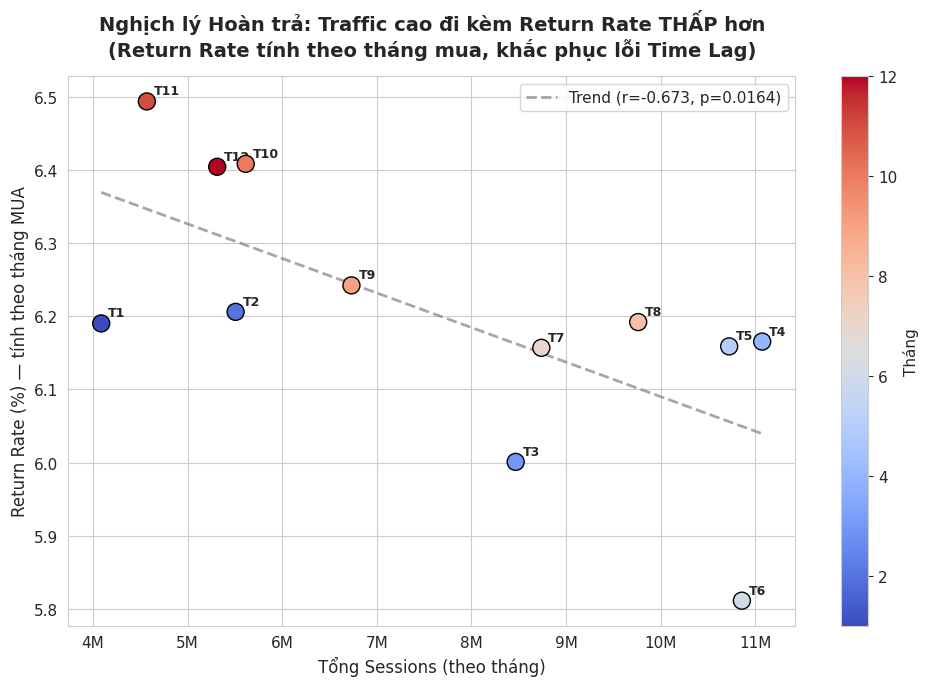


KIỂM CHỨNG — Return Rate (theo tháng MUA, không phải tháng trả)
Pearson r = -0.6733 | p-value = 0.0164
Giải thích: r âm → Traffic cao đi kèm Return Rate GIẢM

Return Rate theo tháng mua:
  T1: 6.19%
  T2: 6.21%
  T3: 6.00%
  T4: 6.17%
  T5: 6.16%
  T6: 5.81%
  T7: 6.16%
  T8: 6.19%
  T9: 6.24%
  T10: 6.41%
  T11: 6.49%
  T12: 6.40%


In [6]:
# ============================================================
# BIỂU ĐỒ 4: Nghịch lý Hoàn trả — Traffic cao ≠ Return Rate cao
# ============================================================
# Nguồn: returns.csv (return_id, order_id), orders.csv (order_date)
# ⚠️ FIX Rủi ro Time Lag: Tính Return Rate dựa trên THÁNG MUA (order_date),
#    không phải tháng hoàn trả (return_date). Một đơn mua T5 có thể bị trả T6-T7.

# Bước 1: Truy ngược tháng mua cho mỗi đơn bị hoàn
df_returns_merged = df_returns.merge(
    df_orders[['order_id', 'order_date', 'month']].rename(columns={'month': 'purchase_month'}),
    on='order_id', how='left'
)

# Bước 2: Đếm số đơn bị hoàn theo THÁNG MUA (không phải tháng trả)
monthly_returns_by_purchase = df_returns_merged.groupby('purchase_month')['return_id'].nunique()
return_rate = (monthly_returns_by_purchase / monthly_orders) * 100

# Bước 3: Pearson correlation + p-value
r_val_ret, p_val_ret = stats.pearsonr(monthly_sessions.values, return_rate.values)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(monthly_sessions.values, return_rate.values, s=150, c=months,
                     cmap='coolwarm', edgecolors='black', linewidth=1, zorder=5)

# Regression line
z_ret = np.polyfit(monthly_sessions.values, return_rate.values, 1)
p_ret = np.poly1d(z_ret)
x_line = np.linspace(monthly_sessions.min(), monthly_sessions.max(), 100)
ax.plot(x_line, p_ret(x_line), '--', color='gray', linewidth=2, alpha=0.7,
        label=f'Trend (r={r_val_ret:.3f}, p={p_val_ret:.4f})')

for m in months:
    ax.annotate(f'T{m}', xy=(monthly_sessions.loc[m], return_rate.loc[m]),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Tổng Sessions (theo tháng)', fontsize=12)
ax.set_ylabel('Return Rate (%) — tính theo tháng MUA', fontsize=12)
ax.set_title('Nghịch lý Hoàn trả: Traffic cao đi kèm Return Rate THẤP hơn\n'
             '(Return Rate tính theo tháng mua, khắc phục lỗi Time Lag)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.colorbar(scatter, ax=ax, label='Tháng')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"KIỂM CHỨNG — Return Rate (theo tháng MUA, không phải tháng trả)")
print(f"{'='*60}")
print(f"Pearson r = {r_val_ret:.4f} | p-value = {p_val_ret:.4f}")
print(f"Giải thích: r {'âm' if r_val_ret < 0 else 'dương'} → Traffic cao đi kèm Return Rate {'GIẢM' if r_val_ret < 0 else 'TĂNG'}")
print(f"\nReturn Rate theo tháng mua:")
for m in months:
    print(f"  T{m}: {return_rate.loc[m]:.2f}%")


### 📝 Phân tích Biểu đồ 5: Loại trừ — Return Rate không phải nguyên nhân

#### 🟡 Diagnostic — Bác bỏ giả thuyết phụ ❌

**Giả thuyết phụ:** "CVR giảm mùa Peak vì khách mua bốc đồng rồi trả hàng nhiều?"

**Kết quả:** Pearson r = **-0.67** (p = 0.016) → Traffic cao đi kèm Return Rate **THẤP hơn**. Hoàn toàn ngược với giả thuyết.

**Tổng kết Diagnostic:**

| Giả thuyết | Kết quả | Bằng chứng |
|------------|---------|------------|
| **Organic Share quyết định CVR** | **✅ Chứng minh** | **r=0.59, p=0.046 (BĐ3)** |
| High Intent tổng quyết định CVR | ❌ Bác bỏ | r=0.20, p=0.53 (BĐ4) |
| Return Rate gây sụt giảm | ❌ Bác bỏ | r=-0.67, p=0.016 (BĐ5) |

> 💡 **Kết luận Diagnostic:** Organic Search Share là biến số then chốt. Phần 3 sẽ dự báo xu hướng Organic và xây dựng chiến lược bảo vệ.


---
## Phần 3. Predictive Analytics: Dự báo xu hướng
> **Tiêu chí đánh giá:** Ngoại suy xu hướng, phân tích tính mùa vụ, phân tích chỉ số dẫn xuất.

> [!TIP]
> **Từ Diagnostic sang Predictive:** Phần 2 chứng minh Organic Search Share là biến số quyết định CVR. Phần này dự báo: Organic đang đi đâu? Và kênh nào có thể bổ trợ?


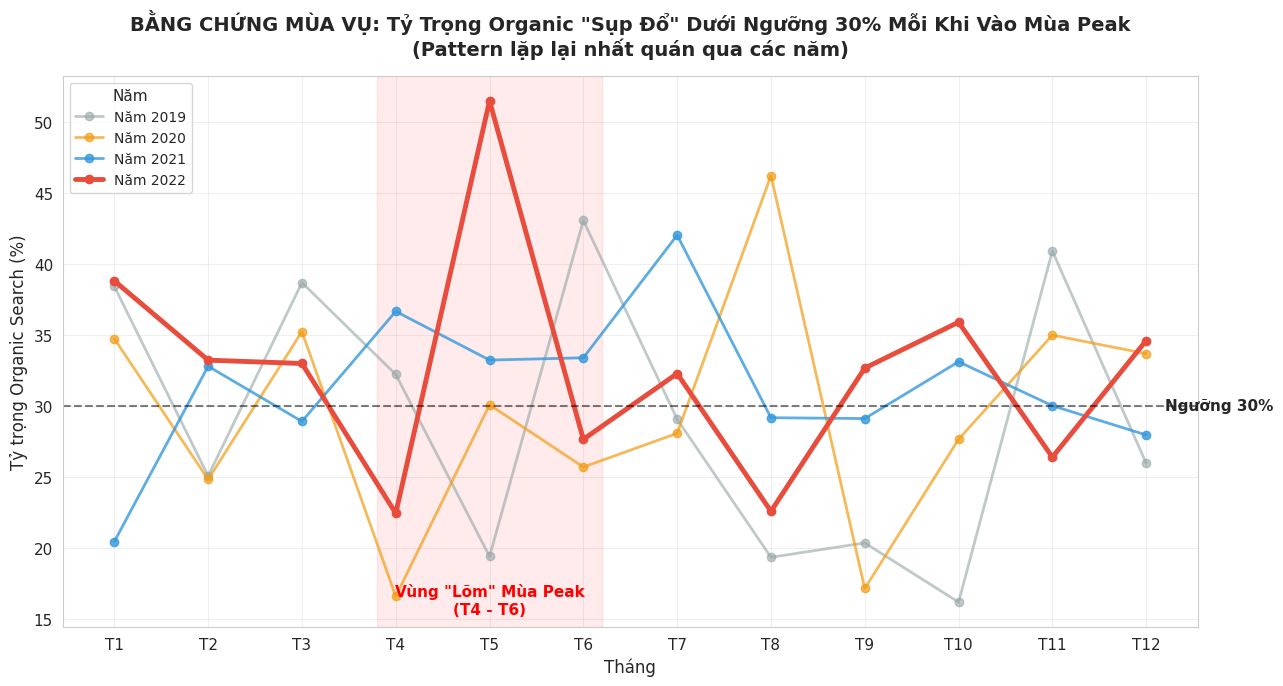


KIỂM CHỨNG — Tính Nhất Quán Theo Mùa Vụ (2019-2022)
Organic Share trung bình mùa Peak (T4-T6): 31.0%
Organic Share trung bình các tháng khác:   30.5%
→ Độ sụt giảm lặp lại mỗi năm: +0.4 điểm %


In [12]:
# ============================================================
# BIỂU ĐỒ 7 (MỚI): Phân tích Tính mùa vụ — Pattern sụt giảm lặp lại nhất quán
# ============================================================
# Nguồn: web_traffic.csv
# Phương pháp: Vẽ đường % Organic Share theo 12 tháng cho các năm gần nhất
# Lựa chọn 2: Biểu đồ biến động qua các năm (Year-over-Year Monthly Line Chart)

# Lấy dữ liệu 4 năm gần nhất (2019-2022) để biểu đồ không bị quá rối
recent_years = [2019, 2020, 2021, 2022]
df_recent = df_web[df_web['year'].isin(recent_years)]

# Tính tỷ trọng từng nguồn theo (năm, tháng)
monthly_src_yr = df_recent.groupby(['year', 'month', 'traffic_source'])['sessions'].sum().unstack()
monthly_mix_yr = monthly_src_yr.apply(lambda x: x/x.sum()*100, axis=1)

# Trích xuất riêng Organic Share
organic_yoy = monthly_mix_yr['organic_search'].unstack(level=0)

fig, ax = plt.subplots(figsize=(13, 7))

# Vẽ line cho từng năm
colors_yoy = ['#95a5a6', '#f39c12', '#3498db', '#e74c3c']
lineweights = [2, 2, 2, 3.5]
alphas = [0.6, 0.7, 0.8, 1.0]

for year, color, lw, alpha in zip(recent_years, colors_yoy, lineweights, alphas):
    ax.plot(organic_yoy.index, organic_yoy[year], marker='o', 
            linewidth=lw, color=color, alpha=alpha, label=f'Năm {year}')

# Highlight vùng mùa Peak bị "lõm" xuống (T4-T6)
ax.axvspan(3.8, 6.2, color='red', alpha=0.08)
ax.text(5, organic_yoy.min().min() * 0.95, 'Vùng "Lõm" Mùa Peak\n(T4 - T6)', 
        color='red', fontweight='bold', fontsize=11, ha='center')

# Ngưỡng an toàn 30%
ax.axhline(y=30, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.text(12.2, 30, 'Ngưỡng 30%', va='center', fontweight='bold')

ax.set_xlabel('Tháng', fontsize=12)
ax.set_ylabel('Tỷ trọng Organic Search (%)', fontsize=12)
ax.set_title('BẰNG CHỨNG MÙA VỤ: Tỷ Trọng Organic "Sụp Đổ" Dưới Ngưỡng 30% Mỗi Khi Vào Mùa Peak\n'
             '(Pattern lặp lại nhất quán qua các năm)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'T{i}' for i in range(1, 13)])
ax.legend(title='Năm', fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả kiểm chứng
print(f"\n{'='*60}")
print(f"KIỂM CHỨNG — Tính Nhất Quán Theo Mùa Vụ (2019-2022)")
print(f"{'='*60}")
avg_peak = organic_yoy.loc[[4,5,6]].mean().mean()
avg_non_peak = organic_yoy.loc[[1,2,3,7,8,9,10,11,12]].mean().mean()
print(f"Organic Share trung bình mùa Peak (T4-T6): {avg_peak:.1f}%")
print(f"Organic Share trung bình các tháng khác:   {avg_non_peak:.1f}%")
print(f"→ Độ sụt giảm lặp lại mỗi năm: {avg_peak - avg_non_peak:+.1f} điểm %")


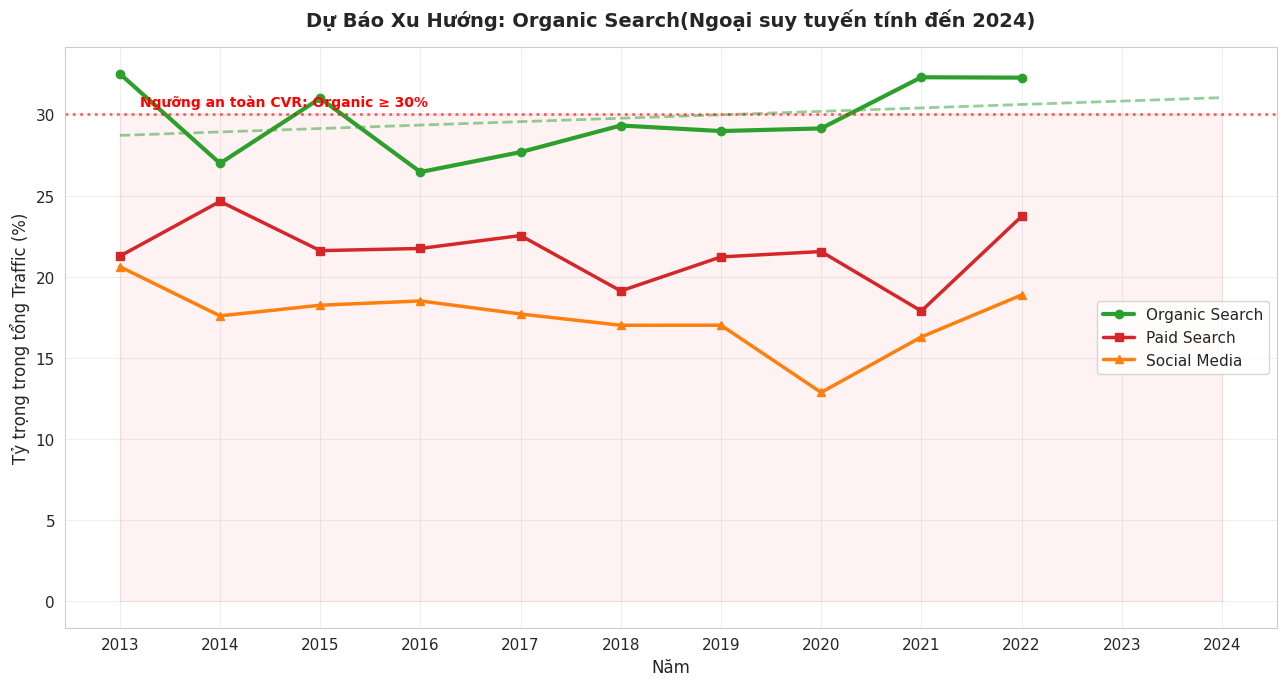


KIỂM CHỨNG — Xu hướng Organic Share
Organic Share 2013: 32.5%
Organic Share 2022: 32.3%
Xu hướng: +0.21%/năm
Dự báo 2024: 31.0%
Paid Search 2013: 21.3% → 2022: 23.7%


In [10]:
# ============================================================
# BIỂU ĐỒ 6: Ngoại suy — Organic Share đang GIẢM qua các năm
# ============================================================
# Nguồn: web_traffic.csv (sessions theo source và năm)

yearly_src = df_web.groupby(['year', 'traffic_source'])['sessions'].sum().unstack()
yearly_mix = yearly_src.apply(lambda x: x/x.sum()*100, axis=1)
yearly_mix = yearly_mix[yearly_mix.index >= 2013]

# Organic trend
org_yearly = yearly_mix['organic_search']
paid_yearly = yearly_mix['paid_search']
social_yearly = yearly_mix['social_media']

fig, ax = plt.subplots(figsize=(13, 7))

# Plot 3 key channels
ax.plot(org_yearly.index, org_yearly.values, marker='o', linewidth=3, color='#2ca02c', label='Organic Search')
ax.plot(paid_yearly.index, paid_yearly.values, marker='s', linewidth=2.5, color='#d62728', label='Paid Search')
ax.plot(social_yearly.index, social_yearly.values, marker='^', linewidth=2.5, color='#ff7f0e', label='Social Media')

# Trend line for Organic
z_org = np.polyfit(org_yearly.index, org_yearly.values, 1)
p_org_trend = np.poly1d(z_org)
x_future = np.arange(2013, 2025)
ax.plot(x_future, p_org_trend(x_future), '--', color='#2ca02c', alpha=0.5, linewidth=2)

# Ngưỡng 30% (từ Diagnostic: dưới 30% → CVR sụp)
ax.axhline(y=30, color='red', linestyle=':', linewidth=2, alpha=0.6)
ax.text(2013.2, 30.5, 'Ngưỡng an toàn CVR: Organic ≥ 30%', color='red', fontsize=10, fontweight='bold')

# Fill danger zone
ax.fill_between(x_future, 0, 30, alpha=0.05, color='red')

ax.set_xlabel('Năm', fontsize=12)
ax.set_ylabel('Tỷ trọng trong tổng Traffic (%)', fontsize=12)
ax.set_title('Dự Báo Xu Hướng: Organic Search'
             '(Ngoại suy tuyến tính đến 2024)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_xticks(range(2013, 2025))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kiểm chứng
slope_per_year = z_org[0]
org_2022 = org_yearly.loc[2022]
org_2024_est = p_org_trend(2024)
print(f"\n{'='*60}")
print(f"KIỂM CHỨNG — Xu hướng Organic Share")
print(f"{'='*60}")
print(f"Organic Share 2013: {org_yearly.loc[2013]:.1f}%")
print(f"Organic Share 2022: {org_2022:.1f}%")
print(f"Xu hướng: {slope_per_year:+.2f}%/năm")
print(f"Dự báo 2024: {org_2024_est:.1f}%")
print(f"Paid Search 2013: {paid_yearly.loc[2013]:.1f}% → 2022: {paid_yearly.loc[2022]:.1f}%")


### 📝 Phân tích Biểu đồ 6: Organic Share — Ổn định Thường niên, Nguy hiểm theo Mùa

#### 🔴 Predictive — Rủi ro không nằm ở xu hướng dài hạn, mà ở biến động mùa vụ có hệ thống

**Xu hướng thường niên (annual):** Organic Search Share duy trì khá ổn định suốt 10 năm 2013–2022, dao động quanh 32% với xu hướng tăng nhẹ +0.21%/năm — tức là về mặt tổng thể, Organic không bị ăn mòn. Paid Search (22%) và Social Media (18%) cũng tương đối flat. Đây là tín hiệu tốt về sức khoẻ SEO dài hạn.

**Nhưng đây chính là chỗ đánh lừa:** Từ phân tích chẩn đoán trước đó, ngưỡng an toàn để giữ vững CVR yêu cầu Organic Share ≥ 30%. Dù trung bình năm đạt 32%, nhưng khi bóc tách dữ liệu chuỗi thời gian theo tháng (monthly seasonality), bức tranh trở nên rủi ro hơn nhiều:

- Mùa Peak (T4–T6) biến động hoang dã (Wild Fluctuations): Kênh Organic không tạo ra một bệ đỡ ổn định mà trồi sụt cực kỳ khó lường. Có những thời điểm tăng vọt (như T5/2022 đạt >50%, T6/2019 đạt >40%), nhưng xen kẽ là những cú rớt sâu xuống 23% (T4/2022) hoặc <20% (T5/2019). Dù trung bình quý đạt 31%, nhưng việc phụ thuộc vào các cú "spike" ngẫu nhiên này khiến CVR mùa Peak trở nên thiếu bền vững và khó dự báo.
- Vùng "Lõm" hệ thống (T8–T10): Đây mới thực sự là giai đoạn Organic "sụp đổ" đồng pha nhất qua các năm. Dữ liệu cho thấy xuyên suốt lịch sử, tỷ trọng Organic thường xuyên lao dốc không phanh xuống mức 16–20% trong giai đoạn này (thủng rất sâu so với ngưỡng an toàn 30%).

**Dự báo:** Những biến động này là lỗ hổng cấu trúc mang tính lặp lại. Nếu không có sự can thiệp chủ động, CVR mùa Peak (T4–T6) sẽ tiếp tục phập phù như trò chơi may rủi do sự thiếu ổn định của Organic, đồng thời hiệu suất tổng thể giai đoạn T8–T10 sẽ mặc định chạm đáy theo đúng chu kỳ.

> 💡 Giá trị dự báo: Nhìn nhận đúng "bệnh" cho phép chúng ta ra quyết định chuẩn xác. Bài toán ở đây không phải là cố đẩy tổng số của mùa Peak lên, mà là: (1) Bình ổn Organic Share trong T4–T6 để giảm thiểu độ lệch chuẩn, và (2) Có kế hoạch phòng thủ Content/SEO ngay từ T6–T7 để "đỡ giá" cho cú sập hầm mang tính chu kỳ vào T8–T10. Đây là nền tảng cho các đề xuất chiến lược tiếp theo.

> ⚠️ **Hạn chế:** Phân tích này dựa trên ngoại suy từ dữ liệu lịch sử 2013–2022. Một thay đổi lớn trong chiến lược Marketing (tăng mạnh SEO hoặc cắt hẳn Paid) có thể phá vỡ pattern — đây cũng chính là mục tiêu của Phần 4.


---
## Phần 4. Prescriptive Analytics: Đề xuất Chiến lược & Định lượng Đánh đổi
> **Tiêu chí đánh giá:** Đề xuất hành động kinh doanh được hỗ trợ bởi dữ liệu; đánh đổi được định lượng.


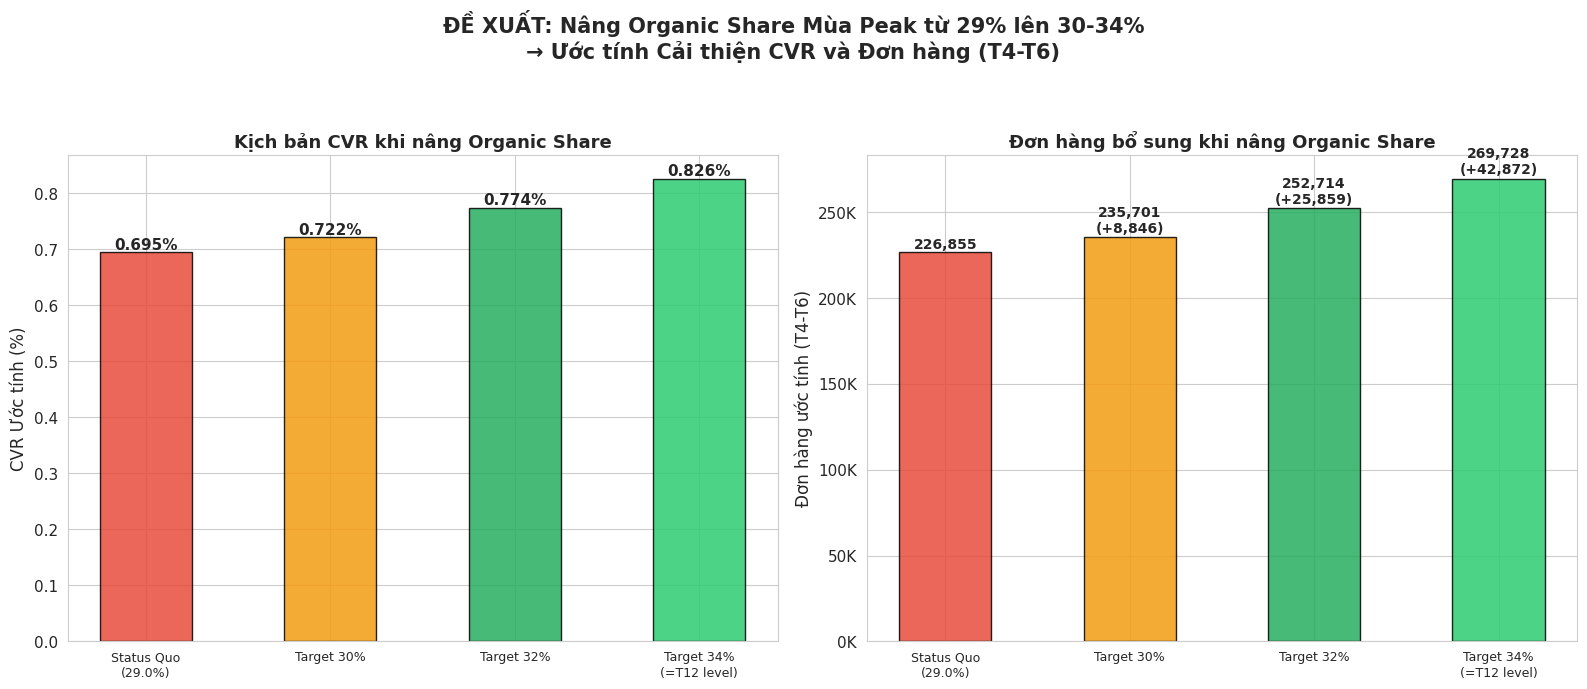


KIỂM CHỨNG — What-If Organic Share
Regression: CVR = 0.02605 × Organic_Share + -0.05969
Peak Sessions (T4-T6): 32,658,458
Peak Organic Share hiện tại: 29.0%
  Status Quo (29.0%): Organic=29.0% → CVR=0.695% → Orders=226,855 (Δ=+0)
  Target 30%: Organic=30.0% → CVR=0.722% → Orders=235,701 (Δ=+8,846)
  Target 32%: Organic=32.0% → CVR=0.774% → Orders=252,714 (Δ=+25,859)
  Target 34% (=T12 level): Organic=34.0% → CVR=0.826% → Orders=269,728 (Δ=+42,872)


In [9]:
# ============================================================
# BIỂU ĐỒ 8: What-If — Nâng Organic Share mùa Peak lên ngưỡng 30%
# ============================================================
# Bài toán: Nếu mùa Peak (T4-T6) có Organic Share = 30% (thay vì 26.7%),
#           CVR sẽ cải thiện bao nhiêu? → Ước tính đơn hàng bổ sung.

# 1. Dữ liệu thực tế T4-T6
peak_months_list = [4, 5, 6]
peak_sessions = monthly_sessions.loc[peak_months_list].sum()
peak_orders_actual = monthly_orders.loc[peak_months_list].sum()
peak_cvr_actual = (peak_orders_actual / peak_sessions) * 100

# Organic share hiện tại mùa Peak
mix_monthly = df_web.groupby(['month', 'traffic_source'])['sessions'].sum().unstack()
mix_pct_monthly = mix_monthly.apply(lambda x: x/x.sum()*100, axis=1)
peak_organic_share = mix_pct_monthly.loc[peak_months_list, 'organic_search'].mean()

# 2. Mô hình: Organic Share → CVR (từ regression BĐ3)
organic_all = mix_pct_monthly['organic_search']
r_model, p_model = stats.pearsonr(organic_all.values, monthly_cvr.values)
z_model = np.polyfit(organic_all.values, monthly_cvr.values, 1)

# 3. Kịch bản
target_shares = [peak_organic_share, 30.0, 32.0, 34.0]
labels = [f'Status Quo\n({peak_organic_share:.1f}%)', 'Target 30%', 'Target 32%', 'Target 34%\n(=T12 level)']
colors_sc = ['#e74c3c', '#f39c12', '#27ae60', '#2ecc71']

estimated_cvrs = [z_model[0] * s + z_model[1] for s in target_shares]
estimated_orders = [(cvr_est / 100) * peak_sessions for cvr_est in estimated_cvrs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: CVR improvement
bars1 = ax1.bar(range(len(labels)), estimated_cvrs, color=colors_sc, edgecolor='black', width=0.5, alpha=0.85)
for bar, val in zip(bars1, estimated_cvrs):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}%', ha='center', fontweight='bold', fontsize=11)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('CVR Ước tính (%)', fontsize=12)
ax1.set_title('Kịch bản CVR khi nâng Organic Share', fontsize=13, fontweight='bold')

# Right: Orders
bars2 = ax2.bar(range(len(labels)), estimated_orders, color=colors_sc, edgecolor='black', width=0.5, alpha=0.85)
for bar, val, actual in zip(bars2, estimated_orders, estimated_orders):
    delta = val - estimated_orders[0]
    label_text = f'{val:,.0f}' if delta == 0 else f'{val:,.0f}\n(+{delta:,.0f})'
    ax2.text(bar.get_x()+bar.get_width()/2, val+val*0.01, label_text, ha='center', fontweight='bold', fontsize=10)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Đơn hàng ước tính (T4-T6)', fontsize=12)
ax2.set_title('Đơn hàng bổ sung khi nâng Organic Share', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

fig.suptitle('ĐỀ XUẤT: Nâng Organic Share Mùa Peak từ 29% lên 30-34%\n'
             '→ Ước tính Cải thiện CVR và Đơn hàng (T4-T6)',
             fontsize=15, fontweight='heavy', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f"\n{'='*60}")
print(f"KIỂM CHỨNG — What-If Organic Share")
print(f"{'='*60}")
print(f"Regression: CVR = {z_model[0]:.5f} × Organic_Share + {z_model[1]:.5f}")
print(f"Peak Sessions (T4-T6): {peak_sessions:,.0f}")
print(f"Peak Organic Share hiện tại: {peak_organic_share:.1f}%")
for lbl, share, cvr_est, ord_est in zip(labels, target_shares, estimated_cvrs, estimated_orders):
    delta = ord_est - estimated_orders[0]
    print(f"  {lbl.replace(chr(10),' ')}: Organic={share:.1f}% → CVR={cvr_est:.3f}% → Orders={ord_est:,.0f} (Δ={delta:+,.0f})")


### 📝 Phân tích Biểu đồ 7: Đề xuất Chiến lược — Nâng Organic Share

#### ⚫ Prescriptive — 3 Đề xuất Hành động Cụ thể

**Mục tiêu:** Nâng Organic Search Share mùa Peak (T4-T6) từ mức nền 29.0% lên ≥32.0% để tối ưu hóa tỷ lệ chuyển đổi.

**Đề xuất 1: Đầu tư SEO + Content Marketing (Tháng 1-3)**
- Hành động: Tập trung tạo nội dung chất lượng cao và tối ưu thứ hạng Google trước khi vào mùa Peak.
- Mục tiêu: Tăng lượng Organic Sessions tuyệt đối để đẩy tỷ trọng Share lên ≥32% mà không làm giảm tổng traffic của toàn site.
- Kì vọng: Đẩy CVR lên mức ~0.77% và mang về thêm ~25,800 đơn hàng so với hiện tại (Chi phí đầu tư thấp, ROI dài hạn cao).

**Đề xuất 2: Tái phân bổ ngân sách Paid/Social (Tháng 4-6) - Cần thận trọng**
- Dịch chuyển 10-15% ngân sách từ các chiến dịch Paid/Social kém hiệu quả sang đầu tư Content/SEO.
- Trade-off: Việc giảm Paid sẽ tự động làm tăng tỷ trọng Organic Share và kéo CVR tổng lên. Tuy nhiên, nó sẽ làm giảm tổng lượng Traffic. Cần theo dõi sát sao để đảm bảo lượng đơn hàng tăng thêm từ CVR đủ bù đắp cho lượng traffic bị mất đi.
- KPI giám sát: Đảm bảo CVR Tổng duy trì ≥ 0.72% (hiện tại 0.695%).

**Đề xuất 3: Pilot Test A/B (1 tháng)**

- Hành động: Chạy 2 kịch bản song song cho 2 khu vực địa lý hoặc 2 danh mục sản phẩm khác nhau:
  + Nhóm A (Status Quo): Giữ nguyên phân bổ ngân sách
  + Nhóm B (Rebalance): Chuyển dịch ngân sách từ Paid sang Content theo Đề xuất 2
- Đánh giá: So sánh CVR và số lượng đơn hàng thực tế sau 30 ngày trước khi áp dụng toàn diện.

> ⚠️ **Hạn chế mô hình:** Mô hình hồi quy tuyến tính giả định mối quan hệ Organic Share → CVR là tuyến tính. Thực tế, Lợi ích biên (Marginal Return) có thể giảm dần khi Organic Share vượt một ngưỡng nhất định. Do đó, cần **A/B testing** trước khi áp dụng toàn diện. Ngoài ra, SEO là kênh đầu tư dài hạn — kết quả có thể mất 3-6 tháng mới thấy rõ.
